<a href="https://colab.research.google.com/github/SiyuL2025/math_629_final/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
X shape     : (99783, 38)
y shape     : (99783,)
n_features  : 38
Train samples : 79,817
Test  samples : 19,938
Class weights (Down/Flat/Up): [1.317 0.671 1.332]
Model           : Bidirectional LSTM
Input features  : 38
Trainable params: 45,827

  Training Bidirectional LSTM
Ep   1/40 | Train Loss 1.1841 | Val Loss 1.0371 | Val Acc 0.4214
Ep   2/40 | Train Loss 1.0673 | Val Loss 1.0152 | Val Acc 0.4415
Ep   3/40 | Train Loss 1.0498 | Val Loss 1.0019 | Val Acc 0.4606
Ep   4/40 | Train Loss 1.0356 | Val Loss 0.9987 | Val Acc 0.4573
Ep   5/40 | Train Loss 1.0272 | Val Loss 0.9953 | Val Acc 0.4588
Ep   6/40 | Train Loss 1.0200 | Val Loss 0.9918 | Val Acc 0.4767
Ep   7/40 | Train Loss 1.0121 | Val Loss 0.9910 | Val Acc 0.4655
Ep   8/40 | Train Loss 1.0063 | Val Loss 0.9879 | Val Acc 0.4727
Ep   9/40 | Train Loss 0.9996 | Val Loss 0.9875 | Val Acc 0.46

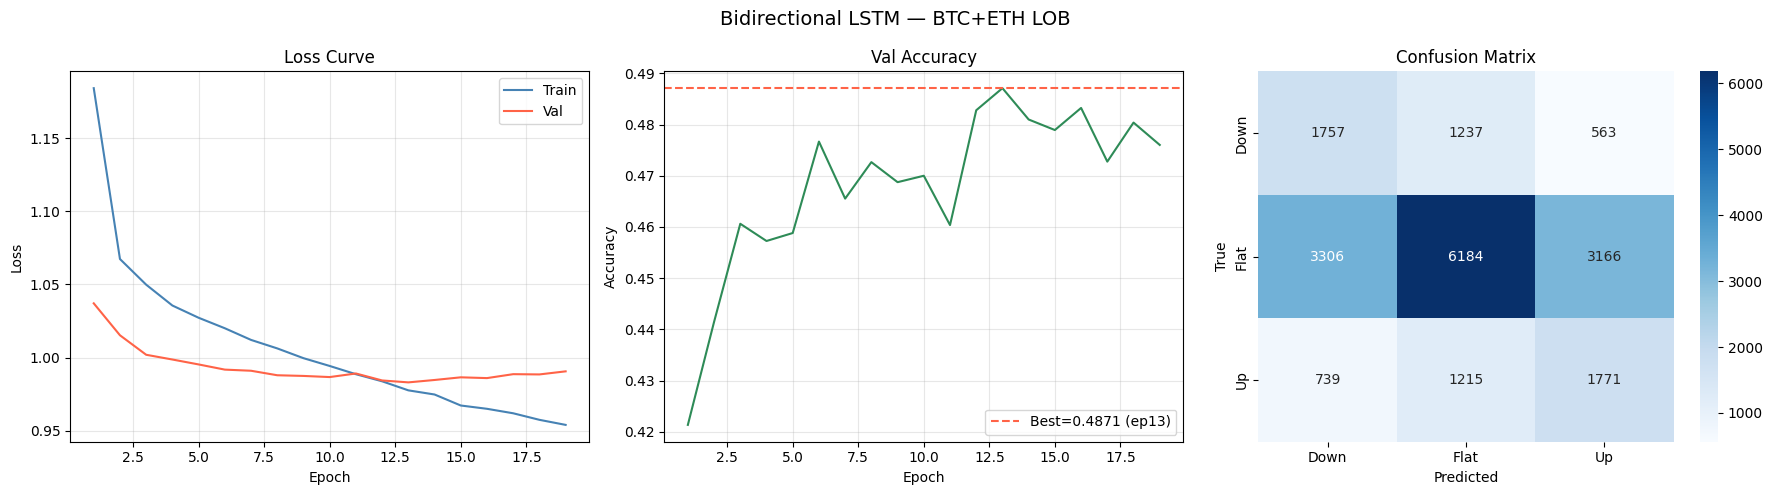

In [ ]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Hyperparameters
# ==========================================
SEED        = 42
SEQ_LEN     = 10
HIDDEN_SIZE = 32
N_LAYERS    = 2
DROPOUT     = 0.4
BATCH_SIZE  = 256
EPOCHS      = 40
LR          = 1e-4
PATIENCE    = 6

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ==========================================
# 2. Load Processed Data
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

save_df = pd.read_csv("/content/drive/MyDrive/lob_full.csv")

split_idx = int((save_df['split'] == 'train').sum())

X_all = save_df.drop(columns=['label', 'split', 'future_return','mid_price']).values.astype(np.float32)
y_all = (save_df['label'].values + 1).astype(np.int64)

returns_all = save_df['future_return'].values

print(f"X shape     : {X_all.shape}")
print(f"y shape     : {y_all.shape}")
print(f"n_features  : {X_all.shape[1]}")

# ==========================================
# 3. Dataset & DataLoaders
# ==========================================
class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]

def build_loaders(X, y, split):
    embargo_gap = 10

    X_tr   = X[:split]
    X_te   = X[split + embargo_gap :]
    y_tr, y_te = y[:split], y[split + embargo_gap :]

    y_tr_targets = y_tr[SEQ_LEN - 1:]
    counts  = np.bincount(y_tr_targets, minlength=3).astype(float)

    smoothed_counts = np.power(counts, 0.75)
    class_w = torch.tensor(smoothed_counts.sum() / (3 * smoothed_counts), dtype=torch.float32).to(DEVICE)
    # class_w = torch.tensor(counts.sum() / (3 * counts), dtype=torch.float32).to(DEVICE)

    train_loader = DataLoader(LOBDataset(X_tr, y_tr, SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(LOBDataset(X_te, y_te, SEQ_LEN),
                              batch_size=BATCH_SIZE * 2, shuffle=False)

    print(f"Train samples : {len(train_loader.dataset):,}")
    print(f"Test  samples : {len(test_loader.dataset):,}")
    print(f"Class weights (Down/Flat/Up): {class_w.cpu().numpy().round(3)}")
    return train_loader, test_loader, class_w

train_loader, test_loader, class_w = build_loaders(X_all, y_all, split_idx)

# ==========================================
# 4. Model Architecture
# ==========================================
class LOBLSTM(nn.Module):
    def __init__(self, n_features: int):
        super().__init__()
        # MODIFIED: Removed input_proj bottleneck. Directly feed n_features to LSTM.
        self.lstm = nn.LSTM(
            input_size    = n_features,
            hidden_size   = HIDDEN_SIZE,
            num_layers    = N_LAYERS,
            batch_first   = True,
            bidirectional = True,
            dropout       = DROPOUT if N_LAYERS > 1 else 0.0,
        )

        self.norm = nn.LayerNorm(HIDDEN_SIZE*2)
        self.head = nn.Sequential(
            nn.Linear(HIDDEN_SIZE*2, HIDDEN_SIZE),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_SIZE, 3),
        )
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param.data)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param.data)
            elif "bias" in name:
                param.data.fill_(0)
                n = param.size(0)
                param.data[n // 4 : n // 2].fill_(1)
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        # MODIFIED: x shape directly goes to LSTM (B, T, n_features)
        _, (h_n, _) = self.lstm(x)

        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h = torch.cat((h_forward, h_backward), dim=1)
        # h = h_n[-1]
        h = self.norm(h)
        return self.head(h)

n_features = X_all.shape[1]

model      = LOBLSTM(n_features).to(DEVICE)
n_params   = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model           : Bidirectional LSTM")
print(f"Input features  : {n_features}")
print(f"Trainable params: {n_params:,}")

# ==========================================
# 5. Training Loop
# ==========================================

criterion = nn.CrossEntropyLoss(weight=class_w)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=2e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_loss = float('inf')
best_acc = 0.0
best_state = None
patience_cnt = 0


print("\n" + "=" * 60)
print("  Training Bidirectional LSTM")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item() * len(yb)
    scheduler.step()
    train_loss = running / len(train_loader.dataset)

    model.eval()
    vloss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = model(Xb)
            vloss += criterion(logits, yb).item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            total += len(yb)

    val_loss = vloss / total
    val_acc  = correct / total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Ep {epoch:3d}/{EPOCHS} | Train Loss {train_loss:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        best_acc = val_acc
        patience_cnt = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stop at epoch {epoch}. Best val loss: {best_loss:.4f} (Val Acc: {best_acc:.4f})")
            break
    # if val_acc > best_acc:
    #     best_acc, patience_cnt = val_acc, 0
    #     best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    # else:
    #     patience_cnt += 1
    #     if patience_cnt >= PATIENCE:
    #         print(f"Early stop at epoch {epoch}. Best val acc: {best_acc:.4f}")
    #         break

model.load_state_dict(best_state)
print(f"\nBest Val Accuracy: {best_acc:.4f}")

# ==========================================
# 6. Evaluation
# ==========================================
model.eval()
all_preds, all_labels = [], []
CONFIDENCE_THRESHOLD = 0.55

with torch.no_grad():
    for Xb, yb in test_loader:
        logits = model(Xb.to(DEVICE))

        probs = torch.softmax(logits, dim=1)
        # preds = torch.ones(probs.size(0), dtype=torch.long, device=DEVICE)
        preds = torch.argmax(logits, dim=1)

        # preds[probs[:, 0] > CONFIDENCE_THRESHOLD] = 0
        # preds[probs[:, 2] > CONFIDENCE_THRESHOLD] = 2

        # max_probs, max_idx = torch.max(probs, dim=1)
        # conflict_mask = (probs[:, 0] > CONFIDENCE_THRESHOLD) & (probs[:, 2] > CONFIDENCE_THRESHOLD)
        # preds[conflict_mask] = max_idx[conflict_mask]

        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

print("\n" + "=" * 60)
print("  Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=["Down", "Flat", "Up"]))

# ==========================================
# 7. Plots
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Bidirectional LSTM — BTC+ETH LOB", fontsize=14)

ep = range(1, len(history["train_loss"]) + 1)
axes[0].plot(ep, history["train_loss"], label="Train", color="steelblue")
axes[0].plot(ep, history["val_loss"],   label="Val",   color="tomato")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

best_ep = int(np.argmax(history["val_acc"])) + 1
axes[1].plot(ep, history["val_acc"], color="seagreen")
axes[1].axhline(best_acc, color="tomato", linestyle="--", label=f"Best={best_acc:.4f} (ep{best_ep})")
axes[1].set_title("Val Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Down","Flat","Up"],
            yticklabels=["Down","Flat","Up"])
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()



[Pure Alpha] TC: 0.0bps | Return: 24.89% | Sharpe: 993.68
[Realistic] TC: 0.5bps | Return: 5.36% | Sharpe: 223.20


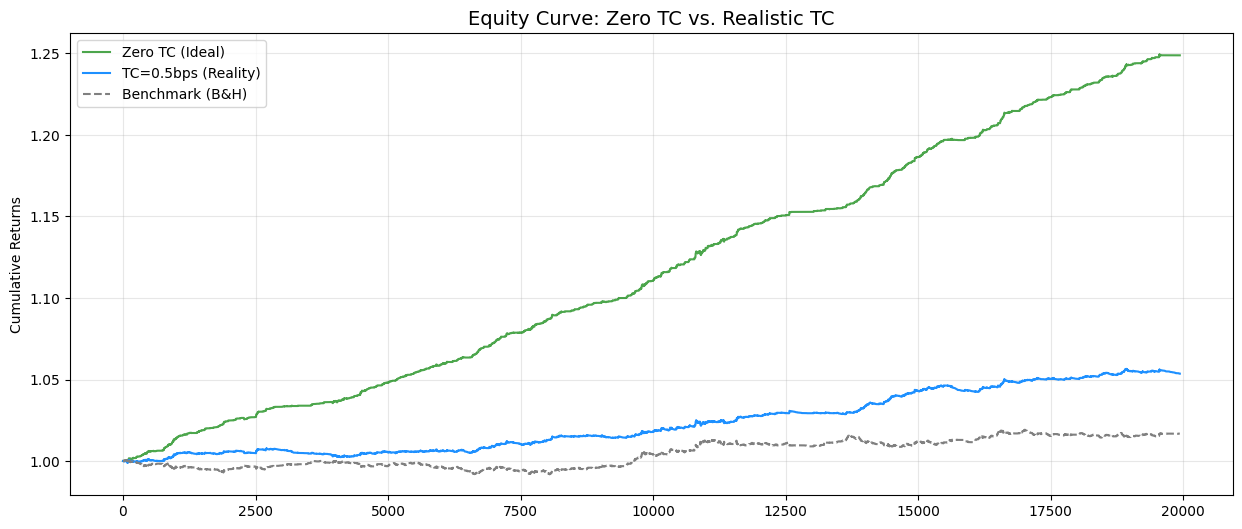

In [ ]:
def run_backtest(df, y_pred, tc=0.00015, embargo=10, name="Strategy"):
    # 1. Align index and map positions
    start = split_idx + embargo + SEQ_LEN - 1
    res = df.iloc[start : start + len(y_pred)].copy()
    res['pos'] = pd.Series(y_pred, index=res.index).map({0: -1, 1: 0, 2: 1})

    # 2. Calculate returns and costs
    res['ret'] = res['mid_price'].pct_change().shift(-1)
    res['turnover'] = res['pos'].diff().fillna(0).abs()
    res['net_ret'] = res['pos'] * res['ret'] - tc * res['turnover']

    # 3. Performance Metrics
    res['cum_ret'] = (1 + res['net_ret'].fillna(0)).cumprod()
    res['benchmark'] = (1 + res['ret'].fillna(0)).cumprod()

    total_ret = (res['cum_ret'].iloc[-1] - 1) * 100
    sharpe = (res['net_ret'].mean() / res['net_ret'].std()) * np.sqrt(365*24*3600) if res['net_ret'].std() > 0 else 0
    print(f"[{name}] TC: {tc*10000:.1f}bps | Return: {total_ret:.2f}% | Sharpe: {sharpe:.2f}")

    return res

# --- Compare TC=0 and TC=0.5bps ---
plt.figure(figsize=(15, 6))

# Scenario 1: No Cost
res_zero = run_backtest(save_df, y_pred, tc=0, embargo=10, name="Pure Alpha")
plt.plot(res_zero['cum_ret'].values, label='Zero TC (Ideal)', color='green', alpha=0.7)

# Scenario 2: With Cost
res_real = run_backtest(save_df, y_pred, tc=0.00005, embargo=10, name="Realistic")
plt.plot(res_real['cum_ret'].values, label='TC=0.5bps (Reality)', color='dodgerblue')

# Benchmark
plt.plot(res_real['benchmark'].values, label='Benchmark (B&H)', color='grey', linestyle='--')

plt.title("Equity Curve: Zero TC vs. Realistic TC", fontsize=14)
plt.ylabel("Cumulative Returns"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [1]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# ==========================================
# 1. Global Setup & Hyperparameters
# ==========================================
# Mount drive once
drive.mount('/content/drive')

SEED        = 42
SEQ_LEN     = 10
HIDDEN_SIZE = 32
N_LAYERS    = 2
DROPOUT     = 0.4
BATCH_SIZE  = 256
EPOCHS      = 40
LR          = 1e-4
PATIENCE    = 6

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Define the 3 tasks
tasks = {
    "Full (PCA + Market)": '/content/drive/MyDrive/lob_full.csv',
    "No PCA (Raw LOB + Market)": '/content/drive/MyDrive/lob_no_pca.csv',
    "No Market (PCA only)": '/content/drive/MyDrive/lob_no_market.csv'
}

# ==========================================
# 2. Reusable Classes & Functions
# ==========================================
class LOBDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len + 1

    def __getitem__(self, i):
        return self.X[i : i + self.seq_len], self.y[i + self.seq_len - 1]

def build_loaders(X, y, split_idx, seq_len, batch_size, device):
    embargo_gap = 10

    X_tr   = X[:split_idx]
    X_te   = X[split_idx + embargo_gap :]
    y_tr, y_te = y[:split_idx], y[split_idx + embargo_gap :]

    y_tr_targets = y_tr[seq_len - 1:]
    counts  = np.bincount(y_tr_targets, minlength=3).astype(float)

    smoothed_counts = np.power(counts, 0.75)
    class_w = torch.tensor(smoothed_counts.sum() / (3 * smoothed_counts), dtype=torch.float32).to(device)

    train_loader = DataLoader(LOBDataset(X_tr, y_tr, seq_len), batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(LOBDataset(X_te, y_te, seq_len), batch_size=batch_size * 2, shuffle=False)

    return train_loader, test_loader, class_w

class LOBLSTM(nn.Module):
    def __init__(self, n_features: int, hidden_size: int, n_layers: int, dropout: float):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(
            input_size    = n_features,
            hidden_size   = hidden_size,
            num_layers    = n_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if n_layers > 1 else 0.0,
        )

        self.norm = nn.LayerNorm(hidden_size * 2)
        self.head = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 3),
        )
        self._init_weights()

    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param.data)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param.data)
            elif "bias" in name:
                param.data.fill_(0)
                n = param.size(0)
                param.data[n // 4 : n // 2].fill_(1)
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h = torch.cat((h_forward, h_backward), dim=1)
        h = self.norm(h)
        return self.head(h)

def run_backtest(df, y_pred, split_idx, seq_len, tc=0.00015, embargo=10, name="Strategy"):
    start = split_idx + embargo + seq_len - 1
    res = df.iloc[start : start + len(y_pred)].copy()
    res['pos'] = pd.Series(y_pred, index=res.index).map({0: -1, 1: 0, 2: 1})

    res['ret'] = res['mid_price'].pct_change().shift(-1)
    res['turnover'] = res['pos'].diff().fillna(0).abs()
    res['net_ret'] = res['pos'] * res['ret'] - tc * res['turnover']

    res['cum_ret'] = (1 + res['net_ret'].fillna(0)).cumprod()
    res['benchmark'] = (1 + res['ret'].fillna(0)).cumprod()

    total_ret = (res['cum_ret'].iloc[-1] - 1) * 100
    sharpe = (res['net_ret'].mean() / res['net_ret'].std()) * np.sqrt(365*24*3600) if res['net_ret'].std() > 0 else 0
    print(f"[{name}] TC: {tc*10000:.1f}bps | Return: {total_ret:.2f}% | Sharpe: {sharpe:.2f}")

    return res

# ==========================================
# 3. Main Processing Function
# ==========================================
def process_task(task_name, file_path):
    print("\n" + "=" * 80)
    print(f"🚀 STARTING TASK: {task_name}")
    print("=" * 80)

    # Ensure fairness by resetting seeds per task
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    # --- Load Data ---
    save_df = pd.read_csv(file_path)
    split_idx = int((save_df['split'] == 'train').sum())

    X_all = save_df.drop(columns=['label', 'split', 'future_return','mid_price']).values.astype(np.float32)
    y_all = (save_df['label'].values + 1).astype(np.int64)

    print(f"X shape     : {X_all.shape}")
    print(f"y shape     : {y_all.shape}")
    print(f"n_features  : {X_all.shape[1]}")

    # --- Build Loaders ---
    train_loader, test_loader, class_w = build_loaders(X_all, y_all, split_idx, SEQ_LEN, BATCH_SIZE, DEVICE)
    print(f"Train samples : {len(train_loader.dataset):,}")
    print(f"Test  samples : {len(test_loader.dataset):,}")
    print(f"Class weights (Down/Flat/Up): {class_w.cpu().numpy().round(3)}\n")

    # --- Model Setup ---
    n_features = X_all.shape[1]
    model = LOBLSTM(n_features, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable params: {n_params:,}\n")

    criterion = nn.CrossEntropyLoss(weight=class_w)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=2e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_loss = float('inf')
    best_acc = 0.0
    best_state = None
    patience_cnt = 0

    # --- Training Loop ---
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item() * len(yb)
        scheduler.step()
        train_loss = running / len(train_loader.dataset)

        model.eval()
        vloss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits = model(Xb)
                vloss += criterion(logits, yb).item() * len(yb)
                correct += (logits.argmax(1) == yb).sum().item()
                total += len(yb)

        val_loss = vloss / total
        val_acc  = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Uncomment below if you want detailed epoch logs
        # print(f"Ep {epoch:3d}/{EPOCHS} | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_acc = val_acc
            patience_cnt = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"Early stop at epoch {epoch}. Best val loss: {best_loss:.4f} (Val Acc: {best_acc:.4f})")
                break

    model.load_state_dict(best_state)
    print(f"✅ Best Val Accuracy for {task_name}: {best_acc:.4f}")

    # --- Evaluation ---
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            logits = model(Xb.to(DEVICE))
            preds = torch.argmax(logits, dim=1)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(yb.numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Down", "Flat", "Up"], zero_division=0))

    # --- Metrics Plots ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{task_name} — Model Training Metrics", fontsize=14)

    ep = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(ep, history["train_loss"], label="Train", color="steelblue")
    axes[0].plot(ep, history["val_loss"],   label="Val",   color="tomato")
    axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")

    best_ep = int(np.argmax(history["val_acc"])) + 1 if history["val_acc"] else 1
    axes[1].plot(ep, history["val_acc"], color="seagreen")
    axes[1].axhline(best_acc, color="tomato", linestyle="--", label=f"Best={best_acc:.4f}")
    axes[1].set_title("Val Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[2],
                xticklabels=["Down","Flat","Up"],
                yticklabels=["Down","Flat","Up"])
    axes[2].set_title("Confusion Matrix")
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")

    plt.tight_layout()
    plt.show()

    # --- Backtesting & Equity Curve ---
    print("\nRunning Backtest...")
    plt.figure(figsize=(15, 6))

    res_zero = run_backtest(save_df, y_pred, split_idx, SEQ_LEN, tc=0, embargo=10, name="Pure Alpha")
    plt.plot(res_zero['cum_ret'].values, label='Zero TC (Ideal)', color='green', alpha=0.7)

    res_real = run_backtest(save_df, y_pred, split_idx, SEQ_LEN, tc=0.00005, embargo=10, name="Realistic")
    plt.plot(res_real['cum_ret'].values, label='TC=0.5bps (Reality)', color='dodgerblue')

    plt.plot(res_real['benchmark'].values, label='Benchmark (B&H)', color='grey', linestyle='--')

    plt.title(f"{task_name} — Equity Curve: Zero TC vs. Realistic TC", fontsize=14)
    plt.ylabel("Cumulative Returns"); plt.legend(); plt.grid(alpha=0.3)
    plt.show()

    print(f"🏁 Finished {task_name}\n")
    return best_acc

# ==========================================
# 4. Execute Tasks
# ==========================================
task_results = {}
for name, path in tasks.items():
    acc = process_task(name, path)
    task_results[name] = acc

print("\n" + "=" * 40)
print("🏆 FINAL SUMMARY OF ACCURACIES")
print("=" * 40)
for name, acc in task_results.items():
    print(f"{name:30s} : {acc:.4f}")

KeyboardInterrupt: 